<a href="https://colab.research.google.com/github/Muskan-Sh-23/Machine-learning/blob/main/Support_Vector_Machine/RBF_SVM_from_Scartch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons  #datset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## Dataset

The Two Moons dataset contains two nonlinear classes, making it suitable for evaluating kernel-based SVMs.

In [17]:
X, Y = make_moons(
    n_samples=300,
    noise=0.15,
    random_state=42
)

In [18]:
#Train-Test split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

## Data Preprocessing

Standardization ensures both features have comparable scales before distance calculations.

In [19]:
#Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
Y_train = np.where(Y_train == 0, -1, 1)
Y_test = np.where(Y_test == 0, -1, 1)

In [21]:
def rbf_kernel(x1, x2, gamma=1):

    distance = np.linalg.norm(x1 - x2) ** 2

    return np.exp(-gamma * distance)

## SMO Optimization

The optimizer updates two Lagrange multipliers (`α`) at a time while keeping the SVM constraints satisfied.

In [22]:
class RBFSVM:

    # Initialize the SVM hyperparameters
    def __init__(self, C=1.0, gamma=1.0, tol=1e-3, max_passes=10):

        self.C = C                    # Regularization parameter
        self.gamma = gamma            # Controls the radius of influence in the RBF kernel
        self.tol = tol                # Tolerance for checking optimality
        self.max_passes = max_passes  # Stop after this many passes with no updates

    # Gaussian (RBF) Kernel
    def kernel(self, x1, x2):

        # Similarity decreases as the distance between points increases
        return np.exp(-self.gamma * np.linalg.norm(x1 - x2) ** 2)

    # Train the model using Sequential Minimal Optimization (SMO)
    def fit(self, X, y):

        n_samples = X.shape[0]

        # Store training data for prediction later
        self.X = X
        self.y = y

        # Initialize Lagrange multipliers (α) to zero
        self.alpha = np.zeros(n_samples)

        # Initialize bias
        self.b = 0

        # Counts consecutive passes with no alpha updates
        passes = 0

        while passes < self.max_passes:

            num_changed = 0

            # Visit every training sample
            for i in range(n_samples):

                # Prediction error for sample i
                Ei = self.decision(X[i]) - y[i]

                # Check whether this point violates the KKT conditions
                if (y[i] * Ei < -self.tol and self.alpha[i] < self.C) or \
                   (y[i] * Ei > self.tol and self.alpha[i] > 0):

                    # Randomly choose another sample j
                    j = np.random.randint(0, n_samples)

                    while j == i:
                        j = np.random.randint(0, n_samples)

                    # Prediction error for sample j
                    Ej = self.decision(X[j]) - y[j]

                    # Save previous alpha values
                    alpha_i_old = self.alpha[i]
                    alpha_j_old = self.alpha[j]

                    # Compute the valid range [L, H] for alpha_j
                    if y[i] != y[j]:
                        L = max(0, self.alpha[j] - self.alpha[i])
                        H = min(self.C, self.C + self.alpha[j] - self.alpha[i])
                    else:
                        L = max(0, self.alpha[i] + self.alpha[j] - self.C)
                        H = min(self.C, self.alpha[i] + self.alpha[j])

                    # No update is possible
                    if L == H:
                        continue

                    # Compute kernel values
                    kii = self.kernel(X[i], X[i])
                    kjj = self.kernel(X[j], X[j])
                    kij = self.kernel(X[i], X[j])

                    # Second derivative term used in the SMO update
                    eta = 2 * kij - kii - kjj

                    # Skip if the update would not be valid
                    if eta >= 0:
                        continue

                    # Update alpha_j
                    self.alpha[j] -= y[j] * (Ei - Ej) / eta

                    # Keep alpha_j inside its valid range
                    self.alpha[j] = np.clip(self.alpha[j], L, H)

                    # Ignore tiny numerical changes
                    if abs(self.alpha[j] - alpha_j_old) < 1e-5:
                        continue

                    # Update alpha_i to maintain the equality constraint
                    self.alpha[i] += y[i] * y[j] * (alpha_j_old - self.alpha[j])

                    # Compute two possible bias values
                    b1 = self.b - Ei \
                         - y[i] * (self.alpha[i] - alpha_i_old) * kii \
                         - y[j] * (self.alpha[j] - alpha_j_old) * kij

                    b2 = self.b - Ej \
                         - y[i] * (self.alpha[i] - alpha_i_old) * kij \
                         - y[j] * (self.alpha[j] - alpha_j_old) * kjj

                    # Choose the appropriate bias
                    if 0 < self.alpha[i] < self.C:
                        self.b = b1
                    elif 0 < self.alpha[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2

                    num_changed += 1

            # Stop if no alpha values changed for several consecutive passes
            if num_changed == 0:
                passes += 1
            else:
                passes = 0

        return self

    # Compute the decision function f(x)
    def decision(self, x):

        # Start with the bias
        result = self.b

        # Add votes from every support vector
        for alpha, yi, xi in zip(self.alpha, self.y, self.X):
            if alpha > 1e-6:
                result += alpha * yi * self.kernel(xi, x)

        return result

    # Predict class labels
    def predict(self, X):

        return np.array([
            1 if self.decision(x) >= 0 else -1
            for x in X
        ])

In [23]:
svm = RBFSVM(
    C=1,
    gamma=1
)

svm.fit(X_train, Y_train)

In [24]:
train_pred = svm.predict(X_train)
test_pred = svm.predict(X_test)

In [25]:
train_acc = accuracy_score(Y_train, train_pred)
test_acc = accuracy_score(Y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9833333333333333
Test Accuracy: 0.9833333333333333


## Support Vectors

Only training samples with non-zero `α` values contribute to the final decision function.

In [26]:
support_vectors = np.sum(svm.alpha > 1e-6)

print("Support Vectors:", support_vectors)

Support Vectors: 46


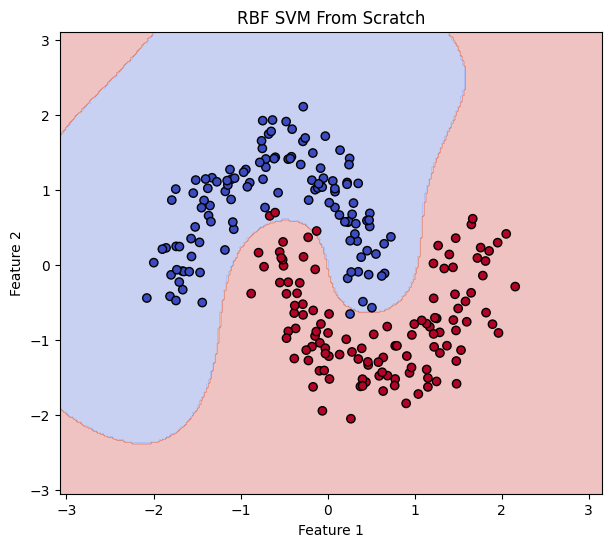

In [27]:
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = svm.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=Y_train,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("RBF SVM From Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Results

| Metric | Value |
|--------|------:|
| Training Accuracy | **98.33%** |
| Test Accuracy | **98.33%** |
| Support Vectors | **46** |

The model achieved identical training and test accuracy on this train-test split, indicating strong generalization. Only 46 support vectors were required to define the nonlinear decision boundary.


## Observations

- The RBF Kernel measures similarity using Euclidean distance.
- Nearby points have stronger influence than distant points.
- SMO learns the support vectors through Lagrange multipliers (`α`).
- The Gaussian kernel produces a smooth nonlinear decision boundary.

## Conclusion

This implementation combines a custom Gaussian (RBF) Kernel with a from-scratch SMO optimizer to classify the Two Moons dataset without using `sklearn.SVC`.